# 18 — Convolution Backward Pass

The convolution forward pass reuses each filter at many spatial positions and often uses overlapping input patches. Its backward pass therefore has one central idea: **accumulate every contribution with `+=`**.

## Learning objectives

- derive the local gradients of one convolution response;
- explain why input and filter gradients accumulate;
- derive the bias gradient;
- implement `dx`, `dweights`, and `dbias`;
- correctly remove spatial padding from `dx`;
- verify all gradients numerically.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.gradient_check import (
    eval_numerical_gradient_array,
    relative_error,
)

np.set_printoptions(precision=3, suppress=True)

## 1. Provided forward pass

We use the forward operation from [Notebook 17](./17_convolution_forward_pass.ipynb). It is included here so this notebook can run independently. The cache stores the quantities needed to reconstruct every forward-pass patch.

In [2]:
def convolution_output_shape(
    input_height, input_width, filter_height, filter_width, padding, stride
):
    """Return spatial output shape for an exactly tiled convolution."""
    height_travel = input_height + 2 * padding - filter_height
    width_travel = input_width + 2 * padding - filter_width
    if stride <= 0 or padding < 0:
        raise ValueError("stride must be positive and padding nonnegative")
    if height_travel < 0 or width_travel < 0:
        raise ValueError("filter cannot be larger than the padded input")
    if height_travel % stride or width_travel % stride:
        raise ValueError("filters must tile the padded input exactly")
    return 1 + height_travel // stride, 1 + width_travel // stride


def conv_forward_naive(x, weights, bias, *, stride=1, padding=0):
    """Compute a naive NCHW convolution and return its cache."""
    num_examples, input_channels, input_height, input_width = x.shape
    num_filters, filter_channels, filter_height, filter_width = weights.shape
    if input_channels != filter_channels or bias.shape != (num_filters,):
        raise ValueError("input, filters, and bias have incompatible shapes")

    output_height, output_width = convolution_output_shape(
        input_height, input_width, filter_height, filter_width, padding, stride
    )
    x_padded = np.pad(
        x, ((0, 0), (0, 0), (padding, padding), (padding, padding))
    )
    dtype = np.result_type(x.dtype, weights.dtype, bias.dtype, np.float32)
    output = np.empty(
        (num_examples, num_filters, output_height, output_width), dtype=dtype
    )

    for n in range(num_examples):
        for f in range(num_filters):
            for i in range(output_height):
                h_start = i * stride
                h_end = h_start + filter_height
                for j in range(output_width):
                    w_start = j * stride
                    w_end = w_start + filter_width
                    patch = x_padded[n, :, h_start:h_end, w_start:w_end]
                    output[n, f, i, j] = (
                        np.sum(patch * weights[f]) + bias[f]
                    )

    return output, (x, weights, bias, stride, padding)

## 2. Backpropagate through one response

For one patch $P$, one filter $W$, and one bias $b$, the forward operation is

$$
y=\sum_{c,u,v}P_{c,u,v}W_{c,u,v}+b.
$$


$c$ — channel index
$u$ — row inside the filter
$v$ — column inside the filter

Let the upstream gradient be

$$
g=\frac{\partial L}{\partial y}.
$$

Because $\partial y/\partial P=W$, $\partial y/\partial W=P$, and $\partial y/\partial b=1$, the chain rule gives

$$
dP=gW,\qquad dW=gP,\qquad db=g.
$$

These are local contributions from one output value. The complete convolution adds contributions from many output values.

### Exercise 1 — One-position gradients

Calculate the three local gradients for the supplied patch, filter, and upstream scalar.

In [3]:
local_patch = np.array([[[1.0, 2.0], [3.0, 4.0]]])
local_filter = np.array([[[2.0, 0.0], [-1.0, 3.0]]])
upstream = 2.5

# apply dpatch = upstream * filter, dfilter = upstream * patch,
# and dbias = upstream.
dpatch = upstream * local_filter
dfilter = upstream * local_patch
dbias = upstream

assert np.allclose(dpatch, [[[5.0, 0.0], [-2.5, 7.5]]])
assert np.allclose(dfilter, [[[2.5, 5.0], [7.5, 10.0]]])
assert np.isclose(dbias, 2.5)
dpatch, dfilter, dbias

(array([[[ 5. ,  0. ],
         [-2.5,  7.5]]]),
 array([[[ 2.5,  5. ],
         [ 7.5, 10. ]]]),
 2.5)

## 3. Why gradients use `+=`

Two kinds of reuse occur in convolution:

- **Overlapping patches:** one input pixel can affect several output positions, so `dx` receives a contribution from every window containing that pixel.
- **Shared parameters:** one filter is used for every image and position, so `dweights[f]` receives a contribution from all those uses.

The multivariable chain rule adds all paths by which a value affects the loss. Assignment with `=` would keep only the final contribution; accumulation with `+=` preserves their sum.

### Exercise 2 — See overlap accumulation

Slide a $2\times2$ all-ones filter over a $3\times3$ input with stride 1. Assume every output receives upstream gradient 1. Accumulate the contribution to each input position.

In [11]:
overlap_filter = np.ones((2, 2))
overlap_dout = np.ones((2, 2))
dx_overlap = np.zeros((3, 3))
stride = 1
filter_size = 2

for output_row in range(2):
    for output_col in range(2):
        # add this output's contribution to its 2x2 input window.
        height_start = output_row*stride
        width_start = output_col*stride
        height_end = height_start + filter_size
        width_end = width_start + filter_size
        # Each loop iteration represents one output position, so it should use one scalar upstream gradient
        dx_overlap[height_start:height_end, width_start:width_end] += overlap_dout[output_row, output_col] * overlap_filter

expected_overlap = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]])
assert np.array_equal(dx_overlap, expected_overlap)
dx_overlap

array([[1., 2., 1.],
       [2., 4., 2.],
       [1., 2., 1.]])

The center pixel has gradient 4 because it belongs to all four windows. A corner belongs to only one. This is a count of gradient paths in this special all-ones example. With general filters and upstream gradients, the contributions need not be positive or equal.

## 4. Bias gradient

Bias $b_f$ is added once to every spatial response produced by filter $f$ for every example. Its derivative is therefore the sum over the batch, output-height, and output-width axes:

$$
db_f=\sum_{n,i,j}dY_{n,f,i,j}.
$$

Here $n$ indexes examples, $f$ filters/output channels, $i$ output rows, and $j$ output columns. The value $dY_{n,f,i,j}$ is the upstream gradient for one output position. Because the same $b_f$ is added at every position produced by filter $f$, its gradient sums over all examples and spatial positions $(n,i,j)$. We do not sum over $f$: each filter has its own bias, so `dbias` retains shape $(F,)$. In NumPy this is `np.sum(dout, axis=(0, 2, 3))`.

### Exercise 3 — Sum the correct axes

Calculate one bias gradient per filter without loops.

In [6]:
bias_dout = np.arange(2 * 3 * 2 * 2, dtype=np.float64).reshape(2, 3, 2, 2)

# sum batch and both spatial axes, retaining the filter axis.
bias_gradient = bias_dout.sum(axis=(0,2,3))

assert bias_gradient.shape == (3,)
assert np.array_equal(bias_gradient, [60.0, 92.0, 124.0])
bias_gradient

array([ 60.,  92., 124.])

## 5. Complete convolution backward pass

At output position $(n,f,i,j)$, let

$$
g=dY_{n,f,i,j}.
$$

The loop adds three contributions:

$$
dX_{pad}[\text{patch}]\mathrel{+}=gW_f,
$$

$$
dW_f\mathrel{+}=gX_{pad}[\text{patch}],
$$

$$
db_f\mathrel{+}=g.
$$

We accumulate `dx_padded` because forward windows were extracted from the padded input. At the end, remove its border to return a gradient with exactly the original input shape. Padding zero requires a separate branch: the slice `0:-0` is empty.

### Exercise 4 — Implement `conv_backward_naive`

Complete the allocations, three local-gradient accumulations, and final removal of padding. Keep the loop structure parallel to the forward pass.

In [7]:
def conv_backward_naive(dout, cache):
    """Backpropagate through a naive NCHW convolution."""
    x, weights, bias, stride, padding = cache
    num_examples, input_channels, input_height, input_width = x.shape
    num_filters, _, filter_height, filter_width = weights.shape
    output_height, output_width = convolution_output_shape(
        input_height, input_width, filter_height, filter_width, padding, stride
    )
    expected_dout_shape = (
        num_examples, num_filters, output_height, output_width
    )
    if dout.shape != expected_dout_shape:
        raise ValueError(f"dout must have shape {expected_dout_shape}")

    x_padded = np.pad(
        x, ((0, 0), (0, 0), (padding, padding), (padding, padding))
    )
    gradient_dtype = np.result_type(
        x.dtype, weights.dtype, bias.dtype, dout.dtype, np.float32
    )

    # Allocate zero-filled gradients so contributions can be accumulated.
    dx_padded = np.zeros(x_padded.shape, dtype=gradient_dtype)
    dweights = np.zeros(weights.shape, dtype=gradient_dtype)
    dbias = np.zeros(bias.shape, dtype=gradient_dtype)

    for n in range(num_examples):
        for f in range(num_filters):
            for i in range(output_height):
                h_start = i * stride
                h_end = h_start + filter_height
                for j in range(output_width):
                    w_start = j * stride
                    w_end = w_start + filter_width
                    patch = x_padded[n, :, h_start:h_end, w_start:w_end]
                    upstream = dout[n, f, i, j]

                    # Add this output value's three local contributions.
                    dx_padded[
                        n, :, h_start:h_end, w_start:w_end
                    ] += upstream * weights[f]
                    dweights[f] += upstream * patch
                    dbias[f] += upstream

    # Remove only the spatial border and return the original input shape.
    if padding == 0:
        dx = dx_padded
    else:
        dx = dx_padded[:, :, padding:-padding, padding:-padding]
    return dx, dweights, dbias

### Why unpadding needs a separate zero-padding branch

`dx_padded` has the shape of the padded forward input because gradient contributions are accumulated at the same coordinates used to extract forward patches. The returned `dx` must instead have the shape of the original `x`, so for positive padding we remove that border from only the height and width axes:

```python
dx = dx_padded[:, :, padding:-padding, padding:-padding]
```

The first two `:` slices preserve every example and channel. The last two slices discard `padding` rows or columns from both sides.

When `padding == 0`, Python interprets `-padding` as `-0`, which is the same index as `0`. The slice `0:-0` is therefore `0:0`, an empty slice—not the complete dimension. In that case no border exists, so we return `dx_padded` directly.

### Exercise 5 — Check shapes and a simple gradient

With an all-ones filter and all-ones upstream gradient, `dx` should reproduce the overlap-count pattern from Exercise 2. Check all returned shapes as well.

In [8]:
simple_x = np.arange(9, dtype=np.float64).reshape(1, 1, 3, 3)
simple_weights = np.ones((1, 1, 2, 2))
simple_bias = np.zeros(1)
simple_output, simple_cache = conv_forward_naive(
    simple_x, simple_weights, simple_bias
)
simple_dout = np.ones_like(simple_output)
simple_dx, simple_dweights, simple_dbias = conv_backward_naive(
    simple_dout, simple_cache
)

assert simple_dx.shape == simple_x.shape
assert simple_dweights.shape == simple_weights.shape
assert simple_dbias.shape == simple_bias.shape
assert np.array_equal(simple_dx[0, 0], expected_overlap)
assert np.array_equal(simple_dweights, [[[[8, 12], [20, 24]]]])
assert np.array_equal(simple_dbias, [4])
simple_dx[0, 0], simple_dweights[0, 0], simple_dbias

(array([[1., 2., 1.],
        [2., 4., 2.],
        [1., 2., 1.]]),
 array([[ 8., 12.],
        [20., 24.]]),
 array([4.]))

## 6. Numerical gradient checking

The forward pass returns an array, while numerical differentiation expects a scalar dependency on each variable. Given fixed upstream gradient `dout`, the checker implicitly forms the scalar proxy

$$
L=\sum_{n,f,i,j}Y_{n,f,i,j}\,dY_{n,f,i,j}.
$$

This does not claim that the real model loss has that formula. It constructs a scalar whose derivative uses exactly the chosen upstream gradient, letting us test one layer in isolation.

### Exercise 6 — Numerically verify all gradients

Use a tiny double-precision convolution with padding 1. Calculate numerical gradients for the input, filters, and bias, then compare them with the analytical backward pass.

In [9]:
generator = np.random.default_rng(42)
check_x = generator.normal(size=(1, 2, 4, 4))
check_weights = generator.normal(size=(2, 2, 3, 3))
check_bias = generator.normal(size=2)
check_output, check_cache = conv_forward_naive(
    check_x, check_weights, check_bias, stride=1, padding=1
)
check_dout = generator.normal(size=check_output.shape)
analytical_dx, analytical_dweights, analytical_dbias = conv_backward_naive(
    check_dout, check_cache
)

# Hold the other arguments and the forward configuration fixed while
# perturbing one argument at a time.
numerical_dx = eval_numerical_gradient_array(
    lambda candidate_x: conv_forward_naive(
        candidate_x, check_weights, check_bias, stride=1, padding=1
    )[0],
    check_x,
    check_dout,
)
numerical_dweights = eval_numerical_gradient_array(
    lambda candidate_weights: conv_forward_naive(
        check_x, candidate_weights, check_bias, stride=1, padding=1
    )[0],
    check_weights,
    check_dout,
)
numerical_dbias = eval_numerical_gradient_array(
    lambda candidate_bias: conv_forward_naive(
        check_x, check_weights, candidate_bias, stride=1, padding=1
    )[0],
    check_bias,
    check_dout,
)


errors = {
    "dx": relative_error(analytical_dx, numerical_dx),
    "dweights": relative_error(analytical_dweights, numerical_dweights),
    "dbias": relative_error(analytical_dbias, numerical_dbias),
}
print(errors)
assert all(error < 1e-8 for error in errors.values())

{'dx': 2.66651800672634e-09, 'dweights': 3.3448527401178727e-10, 'dbias': 7.710714485094771e-12}


### Exercise 7 — Visualize input-gradient accumulation

Display the overlap counts from Exercise 5 and explain why the center receives four contributions, edge centers two, and corners one. Then explain why a real `dx` need not have this symmetric positive pattern.

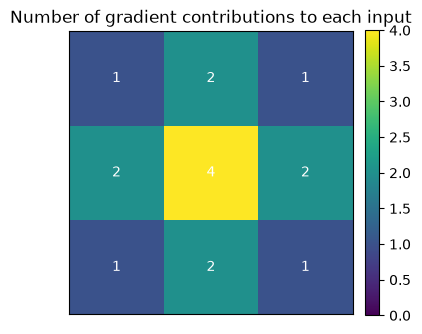

In [10]:
fig, axis = plt.subplots(figsize=(4, 4))
image = axis.imshow(simple_dx[0, 0], cmap="viridis", vmin=0)
for row in range(simple_dx.shape[2]):
    for col in range(simple_dx.shape[3]):
        axis.text(
            col, row, f"{simple_dx[0, 0, row, col]:.0f}",
            ha="center", va="center", color="white"
        )
axis.set_title("Number of gradient contributions to each input")
axis.set_xticks([])
axis.set_yticks([])
fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
plt.show()

The center input belongs to all four convolution windows, so it receives four contributions. Each edge-center belongs to two windows, while each corner belongs to one. The pattern is symmetric and positive because both the filter and dout contain only ones. With learned filters and general upstream gradients, contributions can have different sizes and signs, so a real dx need not be symmetric or positive.

## Reflection

Add a Markdown cell answering:

1. What does `dout[n, f, i, j]` represent?
2. Why is the local patch gradient `upstream * weights[f]`?
3. Why is the local filter gradient `upstream * patch`?
4. Why must `dx_padded` use `+=` rather than `=`?
5. Why must `dweights` accumulate across examples and positions?
6. Which axes are summed to calculate `dbias`, and which axis remains?
7. Why are gradients first accumulated in a padded array?
8. Why does padding zero require a special unpadding branch?
9. Why must each returned gradient have the same shape as its corresponding forward variable?
10. What does numerical gradient checking verify, and what does it not prove?
11. Why does the all-ones example produce a symmetric overlap-count pattern?
12. Which backward-pass accumulation was hardest to understand?

After this notebook, the verified convolution forward and backward functions can be moved into `cs231n_practice/cnn_layers.py` with focused unit tests.

1. Upstram gradient. dout[n, f, i, j] is $\partial L/\partial Y_{n,f,i,j}$: the loss gradient for example $n$, filter $f$, output row $i$, and output column $j$.
2. For one response, $\partial y/\partial P=W$. Multiplying this local derivative by the upstream gradient gives $dP=gW$.
3. For one response, $\partial y/\partial W=P$. Therefore, the local filter contribution is $dW=gP$.
4. the same input item might impact several output that's why gradient should be accumulated among different outputs
5. The same filter (weights) is used for every example and spatial position, so its gradient accumulates contributions from all those uses.
6. filter axis remains because each filter has separate bias. samples and positions are summed
7. the padding has impact on calculating output and loss. Forward patches are selected from the padded input, so backward contributions must first be placed at those same padded coordinates. The padding is cropped afterward to recover dx.
8. if it is zero code will not work properly and proper matrix will not be returned. When padding is zero, padding:-padding becomes 0:-0, which equals 0:0 and returns an empty spatial slice.
9. A gradient contains one partial derivative for every element of its corresponding forward variable, so dx, dweights, and dbias must match the shapes of x, weights, and bias.
10. Numerical checking verifies that the analytical gradient agrees with finite differences for the tested values. It does not prove correctness for every input, validate the entire model, or show that training will succeed.
11. The all-ones filter and all-ones upstream gradient make every path contribute one. The result therefore counts how many overlapping windows contain each pixel, producing a symmetric pattern.
12. Tracking which slice of dx_padded receives each output’s contribution was the hardest part.